### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
# import os
# from dotenv import load_dotenv
# load_dotenv()

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
# os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
# from langchain_openai import ChatOpenAI
# llm=ChatOpenAI(model="gpt-4o")
from langchain_ollama import ChatOllama
llm=ChatOllama(model="qwen2.5:7b")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today? Feel free to ask me any questions or let me know if you need help with anything specific.', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-16T20:55:55.6625381Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9456067300, 'load_duration': 6639333300, 'prompt_eval_count': 30, 'prompt_eval_duration': 470520200, 'eval_count': 29, 'eval_duration': 2321948100, 'logprobs': None, 'model_name': 'qwen2.5:7b'}, id='run--019c683c-e11c-71c3-9d39-b043603b7e9a-0', usage_metadata={'input_tokens': 30, 'output_tokens': 29, 'total_tokens': 59})

In [5]:
from langchain_groq import ChatGroq

llm_groq=ChatOllama(model="qwen2.5:7b")#ChatGroq(model="qwen-qwq-32b")
llm_groq.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content="Hello Krish! Great to meet you. Cricket is indeed a fantastic sport that brings people together. Whether you're playing casually or competitively, it's all about having fun and enjoying the game. Do you have any specific interests within cricket, such as batting, bowling, fielding, or perhaps analyzing match strategies?", additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-16T20:56:02.3867679Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6618366000, 'load_duration': 112758900, 'prompt_eval_count': 39, 'prompt_eval_duration': 291373600, 'eval_count': 64, 'eval_duration': 6090638500, 'logprobs': None, 'model_name': 'qwen2.5:7b'}, id='run--019c683d-0677-7de2-bf5e-492d07521fc1-0', usage_metadata={'input_tokens': 39, 'output_tokens': 64, 'total_tokens': 103})

### We Will start With Creating Nodes

In [6]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

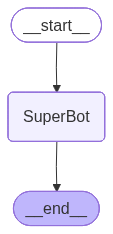

In [7]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='8bfe200b-4586-4530-85e0-3d33ccf5525f'),
  AIMessage(content="Hello Krish! It's nice to meet you. Cricket is indeed a popular sport with a passionate following around the world. Do you have a favorite cricketer or team? Perhaps we could discuss your love for the game further!", additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-16T20:56:07.5915606Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5073882100, 'load_duration': 96016100, 'prompt_eval_count': 39, 'prompt_eval_duration': 287813000, 'eval_count': 47, 'eval_duration': 4641563000, 'logprobs': None, 'model_name': 'qwen2.5:7b'}, id='run--019c683d-20d4-7f73-a3e8-a9eeeab3bfcb-0', usage_metadata={'input_tokens': 39, 'output_tokens': 47, 'total_tokens': 86})]}

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

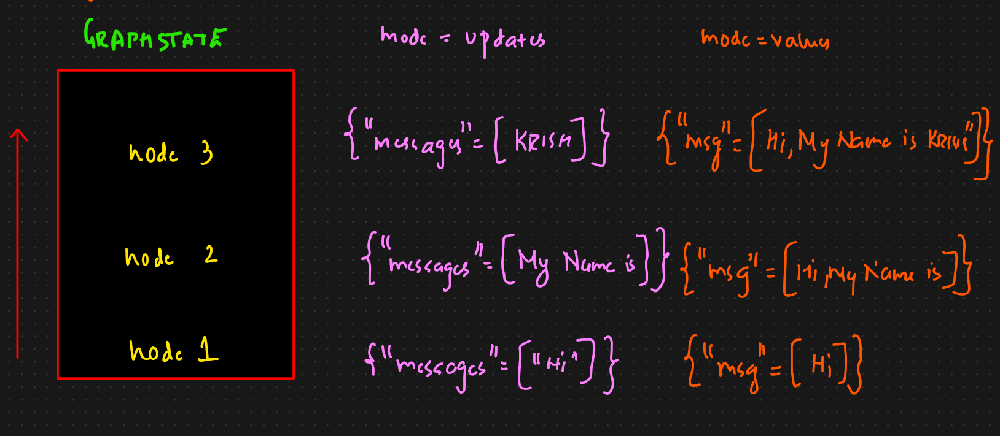

#### Streaming The Responses With Stream Method

In [9]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Krish! Nice to meet you. Cricket is indeed a popular sport, and it's great to have a passion for it. Do you enjoy watching cricket or playing it? Are there any specific teams or players that you particularly admire?", additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-16T20:56:12.6446725Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5033985700, 'load_duration': 105392800, 'prompt_eval_count': 39, 'prompt_eval_duration': 102967800, 'eval_count': 48, 'eval_duration': 4737268000, 'logprobs': None, 'model_name': 'qwen2.5:7b'}, id='run--019c683d-34b9-7ab3-86f1-f211c97a170f-0', usage_metadata={'input_tokens': 39, 'output_tokens': 48, 'total_tokens': 87})]}}


In [10]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='79793eed-77cc-4505-986f-8407b05318ea'), AIMessage(content="Hello Krish! Nice to meet you. Cricket is indeed a popular sport, and it's great to have a passion for it. Do you enjoy watching cricket or playing it? Are there any specific teams or players that you particularly admire?", additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-16T20:56:12.6446725Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5033985700, 'load_duration': 105392800, 'prompt_eval_count': 39, 'prompt_eval_duration': 102967800, 'eval_count': 48, 'eval_duration': 4737268000, 'logprobs': None, 'model_name': 'qwen2.5:7b'}, id='run--019c683d-34b9-7ab3-86f1-f211c97a170f-0', usage_metadata={'input_tokens': 39, 'output_tokens': 48, 'total_tokens': 87}), HumanMessage(content='I also like football', additional_kwargs={}, response_metadata={}, id='ae164fbb-e3

In [11]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Great to hear that, Krish! Both cricket and football (or soccer) are fantastic sports with passionate fans worldwide.\n\nDo you have a favorite team or player in football? And is there anything specific you enjoy about the game—whether it's the thrill of watching matches, playing it yourself, or maybe the strategy involved?\n\nFeel free to share more about your experiences or any teams or players that inspire you!", additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-16T20:56:27.950284Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8620950800, 'load_duration': 100414600, 'prompt_eval_count': 176, 'prompt_eval_duration': 314206100, 'eval_count': 82, 'eval_duration': 8091877500, 'logprobs': None, 'model_name': 'qwen2.5:7b'}, id='run--019c683d-6280-78c2-bb3d-c3ecab4fd4f3-0', usage_metadata={'input_tokens': 176, 'output_tokens': 82, 'total_tokens': 258})]}}


In [12]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='79793eed-77cc-4505-986f-8407b05318ea'), AIMessage(content="Hello Krish! Nice to meet you. Cricket is indeed a popular sport, and it's great to have a passion for it. Do you enjoy watching cricket or playing it? Are there any specific teams or players that you particularly admire?", additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-16T20:56:12.6446725Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5033985700, 'load_duration': 105392800, 'prompt_eval_count': 39, 'prompt_eval_duration': 102967800, 'eval_count': 48, 'eval_duration': 4737268000, 'logprobs': None, 'model_name': 'qwen2.5:7b'}, id='run--019c683d-34b9-7ab3-86f1-f211c97a170f-0', usage_metadata={'input_tokens': 39, 'output_tokens': 48, 'total_tokens': 87}), HumanMessage(content='I also like football', additional_kwargs={}, response_metadata={}, id='ae164fbb-e3

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [15]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Bardia"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Bardia']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019c6899-ea5d-7540-912c-208c427793a2', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='79793eed-77cc-4505-986f-8407b05318ea'), AIMessage(content="Hello Krish! Nice to meet you. Cricket is indeed a popular sport, and it's great to have a passion for it. Do you enjoy watching cricket or playing it? Are there any specific teams or players that you particularly admire?", additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-16T20:56:12.6446725Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5033985700, 'load_duration': 105392800, 'prompt_eval_count': 39, 'prompt_eval_duration': 102967800, 'eval_count': 48, 'eval_duration': 4737268000, 'logprobs': No